In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('~/Desktop/nba-shot-predictor/data/shot_logs.csv')

In [4]:
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df['SHOT_RESULT'].value_counts())

(128069, 21)
    GAME_ID                   MATCHUP LOCATION  W  FINAL_MARGIN  SHOT_NUMBER  \
0  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            1   
1  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            2   
2  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            3   
3  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            4   
4  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            5   

   PERIOD GAME_CLOCK  SHOT_CLOCK  DRIBBLES  ...  SHOT_DIST  PTS_TYPE  \
0       1       1:09        10.8         2  ...        7.7         2   
1       1       0:14         3.4         0  ...       28.2         3   
2       1       0:00         NaN         3  ...       10.1         2   
3       2      11:47        10.3         2  ...       17.2         2   
4       2      10:34        10.9         2  ...        3.7         2   

   SHOT_RESULT   CLOSEST_DEFENDER CLOSEST_DEFENDER_PLAYER_ID  CLOSE_DEF_D

In [5]:
print(df.head())

    GAME_ID                   MATCHUP LOCATION  W  FINAL_MARGIN  SHOT_NUMBER  \
0  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            1   
1  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            2   
2  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            3   
3  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            4   
4  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            5   

   PERIOD GAME_CLOCK  SHOT_CLOCK  DRIBBLES  ...  SHOT_DIST  PTS_TYPE  \
0       1       1:09        10.8         2  ...        7.7         2   
1       1       0:14         3.4         0  ...       28.2         3   
2       1       0:00         NaN         3  ...       10.1         2   
3       2      11:47        10.3         2  ...       17.2         2   
4       2      10:34        10.9         2  ...        3.7         2   

   SHOT_RESULT   CLOSEST_DEFENDER CLOSEST_DEFENDER_PLAYER_ID  CLOSE_DEF_DIST  \
0     

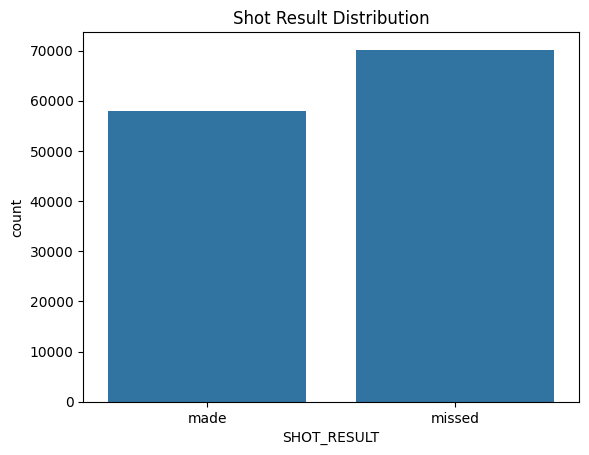

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='SHOT_RESULT', data=df)
plt.title('Shot Result Distribution')
plt.show()

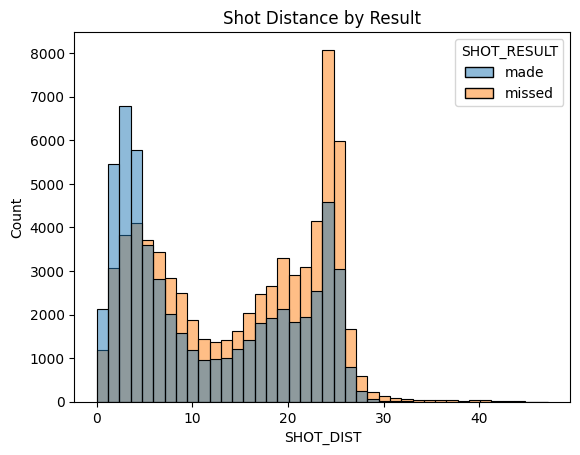

In [7]:
sns.histplot(data=df, x='SHOT_DIST', hue='SHOT_RESULT', bins=40)
plt.title('Shot Distance by Result')
plt.show()

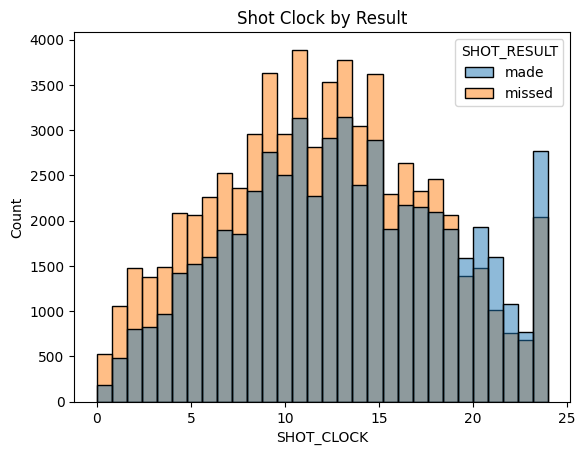

In [8]:
sns.histplot(data=df, x='SHOT_CLOCK', hue='SHOT_RESULT', bins=30)
plt.title('Shot Clock by Result')
plt.show()

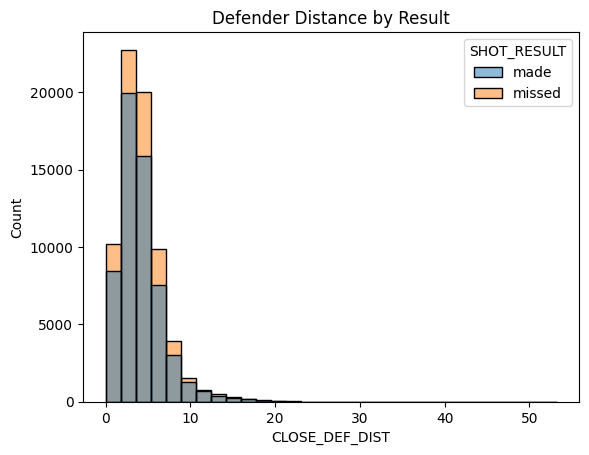

In [9]:
sns.histplot(data=df, x='CLOSE_DEF_DIST', hue='SHOT_RESULT', bins=30)
plt.title('Defender Distance by Result')
plt.show()

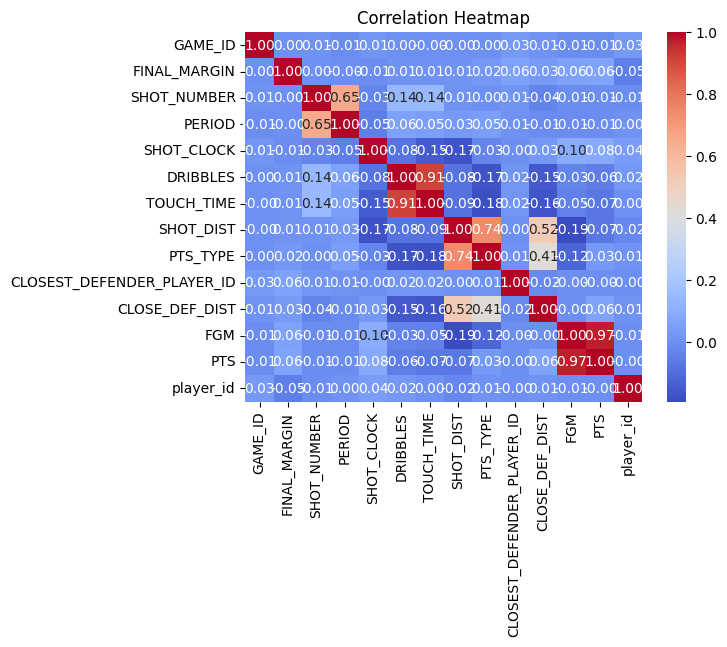

In [10]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
drop_cols = ['FGM', 'PTS', 'DRIBBLES', 'GAME_ID', 
             'CLOSEST_DEFENDER_PLAYER_ID', 'player_id']
df = df.drop(columns=drop_cols)

In [12]:
df.head()

,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,TOUCH_TIME,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSE_DEF_DIST,player_name
0,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.8,1.9,7.7,2,made,"Anderson, Alan",1.3,brian roberts
1,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.4,0.8,28.2,3,missed,"Bogdanovic, Bojan",6.1,brian roberts
2,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,NaN,2.7,10.1,2,missed,"Bogdanovic, Bojan",0.9,brian roberts
3,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.3,1.9,17.2,2,missed,"Brown, Markel",3.4,brian roberts
4,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.9,2.7,3.7,2,missed,"Young, Thaddeus",1.1,brian roberts


In [13]:
df['target'] = (df['SHOT_RESULT'] == 'made').astype(int)
df = df.drop(columns=['SHOT_RESULT'])

In [14]:
df.head()

,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,TOUCH_TIME,SHOT_DIST,PTS_TYPE,CLOSEST_DEFENDER,CLOSE_DEF_DIST,player_name,target
0,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.8,1.9,7.7,2,"Anderson, Alan",1.3,brian roberts,1
1,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.4,0.8,28.2,3,"Bogdanovic, Bojan",6.1,brian roberts,0
2,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,NaN,2.7,10.1,2,"Bogdanovic, Bojan",0.9,brian roberts,0
3,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.3,1.9,17.2,2,"Brown, Markel",3.4,brian roberts,0
4,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.9,2.7,3.7,2,"Young, Thaddeus",1.1,brian roberts,0


In [15]:
df['is_contested'] = (df['CLOSE_DEF_DIST'] < 4).astype(int)

df['shot_zone_bin'] = pd.cut(df['SHOT_DIST'], 
                              bins=[0, 5, 15, 23, 100],
                              labels=['paint', 'midrange', 'three', 'deep'])

df['late_clock'] = (df['SHOT_CLOCK'] <= 4).astype(int)

In [16]:
df.head()

,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,TOUCH_TIME,SHOT_DIST,PTS_TYPE,CLOSEST_DEFENDER,CLOSE_DEF_DIST,player_name,target,is_contested,shot_zone_bin,late_clock
0,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.8,1.9,7.7,2,"Anderson, Alan",1.3,brian roberts,1,1,midrange,0
1,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.4,0.8,28.2,3,"Bogdanovic, Bojan",6.1,brian roberts,0,0,deep,1
2,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,NaN,2.7,10.1,2,"Bogdanovic, Bojan",0.9,brian roberts,0,1,midrange,0
3,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.3,1.9,17.2,2,"Brown, Markel",3.4,brian roberts,0,1,three,0
4,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.9,2.7,3.7,2,"Young, Thaddeus",1.1,brian roberts,0,1,paint,0


In [17]:
# Drop unwanted cols
drop_cols = ['MATCHUP', 'LOCATION', 'W', 'GAME_CLOCK',
             'CLOSEST_DEFENDER', 'player_name',
             'SHOT_NUMBER', 'PERIOD', 'SHOT_CLOCK', 'late_clock']
df = df.drop(columns=drop_cols, errors='ignore')

# Encode shot_zone_bin
df = pd.get_dummies(df, columns=['shot_zone_bin'], drop_first=True)

# Fix bool → int
bool_cols = ['shot_zone_bin_midrange', 'shot_zone_bin_three', 'shot_zone_bin_deep']
df[bool_cols] = df[bool_cols].astype(int)

In [18]:
df.columns

Index(['FINAL_MARGIN', 'TOUCH_TIME', 'SHOT_DIST', 'PTS_TYPE', 'CLOSE_DEF_DIST',
       'target', 'is_contested', 'shot_zone_bin_midrange',
       'shot_zone_bin_three', 'shot_zone_bin_deep'],
      dtype='str')

In [19]:
df.head()

,FINAL_MARGIN,TOUCH_TIME,SHOT_DIST,PTS_TYPE,CLOSE_DEF_DIST,target,is_contested,shot_zone_bin_midrange,shot_zone_bin_three,shot_zone_bin_deep
0,24,1.9,7.7,2,1.3,1,1,1,0,0
1,24,0.8,28.2,3,6.1,0,0,0,0,1
2,24,2.7,10.1,2,0.9,0,1,1,0,0
3,24,1.9,17.2,2,3.4,0,1,0,1,0
4,24,2.7,3.7,2,1.1,0,1,0,0,0


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
num_cols = ['SHOT_DIST', 'CLOSE_DEF_DIST', 'TOUCH_TIME', 'FINAL_MARGIN']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [21]:
df.head()

,FINAL_MARGIN,TOUCH_TIME,SHOT_DIST,PTS_TYPE,CLOSE_DEF_DIST,target,is_contested,shot_zone_bin_midrange,shot_zone_bin_three,shot_zone_bin_deep
0,24,1.9,7.7,2,1.3,1,1,1,0,0
1,24,0.8,28.2,3,6.1,0,0,0,0,1
2,24,2.7,10.1,2,0.9,0,1,1,0,0
3,24,1.9,17.2,2,3.4,0,1,0,1,0
4,24,2.7,3.7,2,1.1,0,1,0,0,0


In [22]:
df.columns

Index(['FINAL_MARGIN', 'TOUCH_TIME', 'SHOT_DIST', 'PTS_TYPE', 'CLOSE_DEF_DIST',
       'target', 'is_contested', 'shot_zone_bin_midrange',
       'shot_zone_bin_three', 'shot_zone_bin_deep'],
      dtype='str')

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
import pickle

rf = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    min_samples_leaf=5, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = rf.predict(X_test)

print("RF AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

pickle.dump(rf, open('final_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

RF AUC: 0.6406776696618373
              precision    recall  f1-score   support

           0       0.62      0.73      0.67     14033
           1       0.59      0.46      0.52     11581

    accuracy                           0.61     25614
   macro avg       0.60      0.60      0.60     25614
weighted avg       0.61      0.61      0.60     25614



In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=70164/57905,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)

print("XGB AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

XGB AUC: 0.633121270951907
              precision    recall  f1-score   support

           0       0.62      0.72      0.67     14033
           1       0.58      0.47      0.52     11581

    accuracy                           0.61     25614
   macro avg       0.60      0.59      0.59     25614
weighted avg       0.60      0.61      0.60     25614



In [25]:
pickle.dump(xgb, open('final_model_xgb.pkl', 'wb'))

In [26]:
pickle.dump(rf, open('final_model.pkl', 'wb'))

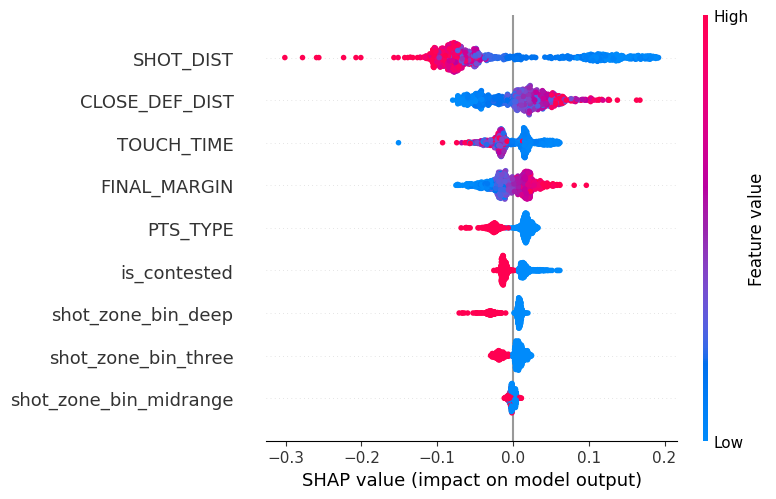

In [30]:
import shap
import matplotlib.pyplot as plt
X_test_sample = X_test.sample(1000, random_state=42).reset_index(drop=True)

explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test_sample)
shap.summary_plot(shap_values_rf[:, :, 1], X_test_sample)
plt.show()

In [29]:
shap_values_rf = explainer_rf.shap_values(X_test_sample)
print(len(shap_values_rf), shap_values_rf[0].shape, X_test_sample.shape)

1000 (9, 2) (1000, 9)


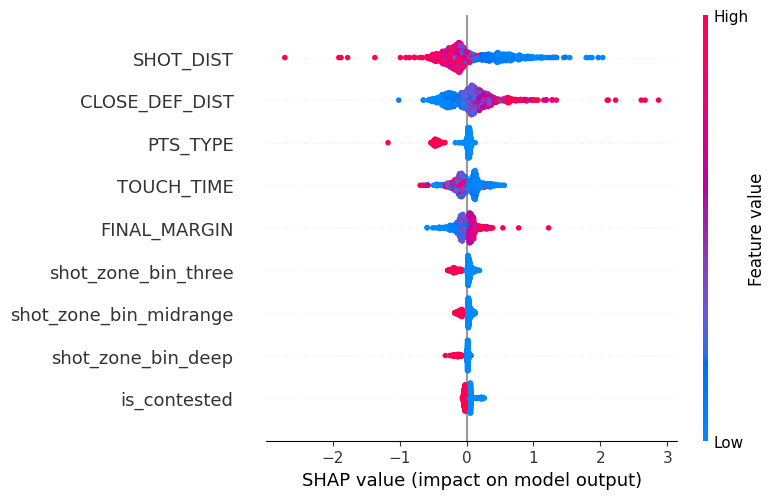

In [31]:
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_sample)
shap.summary_plot(shap_values_xgb, X_test_sample)
plt.show()